In [5]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost imbalanced-learn shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Usi


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Abcom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# IMPORTS & CONFIG
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports complete')

Imports complete


In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd

df_loans = pd.read_csv('..\data\\loan_portfolio.csv', parse_dates=False)
df_txn   = pd.read_csv('..\data\\transactions.csv',   parse_dates=['Timestamp'])

print(f'loan_portfolio.csv loaded — {df_loans.shape}')
print(f'transactions.csv loaded   — {df_txn.shape}')

loan_portfolio.csv loaded — (100, 10)
transactions.csv loaded   — (200, 6)


In [ ]:
# LOAD DATA

print(' LOAN PORTFOLIO')
print(f'Shape: {df_loans.shape}')
display(df_loans.head())
print(df_loans.describe().round(4))
print('Nulls:', df_loans.isnull().sum().to_dict())
print('Customer_Type:', df_loans.Customer_Type.value_counts().to_dict())
print('Past_Default rate:', df_loans.Past_Default.mean().round(4))

print('\ TRANSACTIONS ')
print(f'Shape: {df_txn.shape}')
display(df_txn.head())
print('Fraud_Flag:', df_txn.Fraud_Flag.value_counts().to_dict())
print('Fraud rate:', df_txn.Fraud_Flag.mean().round(4))
print('Transaction_Type:', df_txn.Transaction_Type.value_counts().to_dict())

 LOAN PORTFOLIO
Shape: (100, 10)


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
0,1,Corporate,2676791,0.4700,15,399593,13.3900,36,0,0.2200
1,2,Retail,2740108,0.1500,23,825131,12.8000,36,0,0.0200
2,3,Corporate,4863177,0.2000,15,83686,6.0900,48,0,0.1800
3,4,Corporate,3383597,0.1900,5,77661,5.0500,48,0,0.0700
4,5,Retail,95953,0.6200,21,578535,11.0200,24,0,0.1200


       Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  \
count 100.0000       100.0000        100.0000               100.0000   
mean   50.5000   2671591.5700          0.5538                13.0100   
std    29.0115   1444021.0462          0.2434                 7.1159   
min     1.0000     56790.0000          0.1100                 1.0000   
25%    25.7500   1366360.7500          0.3725                 6.0000   
50%    50.5000   2778969.0000          0.5700                14.5000   
75%    75.2500   3980000.7500          0.7800                19.0000   
max   100.0000   4969003.0000          0.9000                24.0000   

       Loan_Amount  Interest_Rate  Loan_Term_Months  Past_Default       PD  
count     100.0000       100.0000          100.0000      100.0000 100.0000  
mean   509767.2800         9.0689           34.9200        0.1300   0.1572  
std    273871.7620         3.3556           17.1492        0.3380   0.0891  
min     11062.0000         3.4000          

,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag
0,1,57,35200,Withdrawal,2025-09-03 10:47:51.200706,0
1,2,16,25871,Transfer,2025-12-31 10:47:51.200738,0
2,3,56,26710,Withdrawal,2025-09-12 10:47:51.200752,0
3,4,10,5134,Withdrawal,2025-03-29 10:47:51.200763,0
4,5,30,16711,Transfer,2025-06-08 10:47:51.200773,0


Fraud_Flag: {0: 191, 1: 9}
Fraud rate: 0.045
Transaction_Type: {'Withdrawal': 69, 'Payment': 67, 'Transfer': 64}


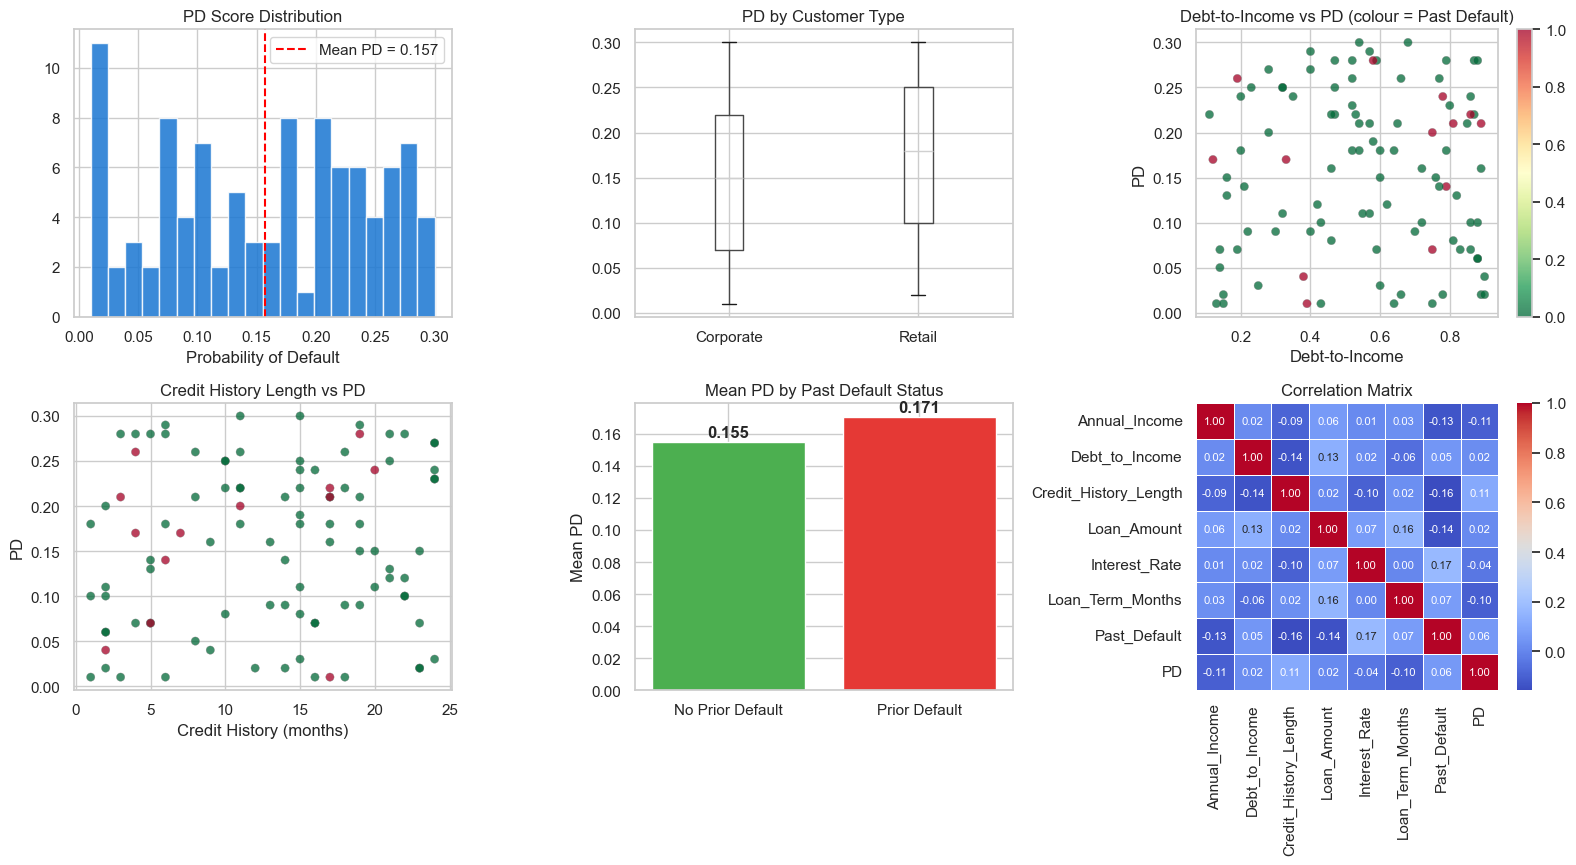

In [11]:
# LOAN EDA ─
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Loan Portfolio — Exploratory Analysis', fontsize=15, fontweight='bold')

# PD distribution
axes[0,0].hist(df_loans['PD'], bins=20, color='#1976D2', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_loans['PD'].mean(), color='red', linestyle='--',
                  label=f"Mean PD = {df_loans['PD'].mean():.3f}")
axes[0,0].set_title('PD Score Distribution')
axes[0,0].set_xlabel('Probability of Default'); axes[0,0].legend()

# PD by Customer Type
df_loans.boxplot(column='PD', by='Customer_Type', ax=axes[0,1])
plt.sca(axes[0,1]); plt.title('PD by Customer Type'); plt.suptitle('')
axes[0,1].set_xlabel('')

# DTI vs PD coloured by Past_Default
sc = axes[0,2].scatter(df_loans['Debt_to_Income'], df_loans['PD'],
                        c=df_loans['Past_Default'], cmap='RdYlGn_r',
                        alpha=0.75, edgecolors='grey', linewidths=0.3)
axes[0,2].set_title('Debt-to-Income vs PD (colour = Past Default)')
axes[0,2].set_xlabel('Debt-to-Income'); axes[0,2].set_ylabel('PD')
plt.colorbar(sc, ax=axes[0,2])

# Credit History vs PD
axes[1,0].scatter(df_loans['Credit_History_Length'], df_loans['PD'],
                  c=df_loans['Past_Default'], cmap='RdYlGn_r',
                  alpha=0.75, edgecolors='grey', linewidths=0.3)
axes[1,0].set_title('Credit History Length vs PD')
axes[1,0].set_xlabel('Credit History (months)'); axes[1,0].set_ylabel('PD')

# Mean PD: Prior Default vs None
pd_by_default = df_loans.groupby('Past_Default')['PD'].mean()
bars = axes[1,1].bar(
    ['No Prior Default', 'Prior Default'],
    pd_by_default.values,
    color=['#4CAF50', '#E53935'], edgecolor='white'
)
for bar in bars:
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.003,
                   f'{bar.get_height():.3f}', ha='center', fontweight='bold')
axes[1,1].set_title('Mean PD by Past Default Status'); axes[1,1].set_ylabel('Mean PD')

# Correlation heatmap
num_cols = ['Annual_Income','Debt_to_Income','Credit_History_Length',
            'Loan_Amount','Interest_Rate','Loan_Term_Months','Past_Default','PD']
corr = df_loans[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,2], linewidths=0.4, annot_kws={'size': 8})
axes[1,2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_loans.png', dpi=120, bbox_inches='tight')
plt.show()

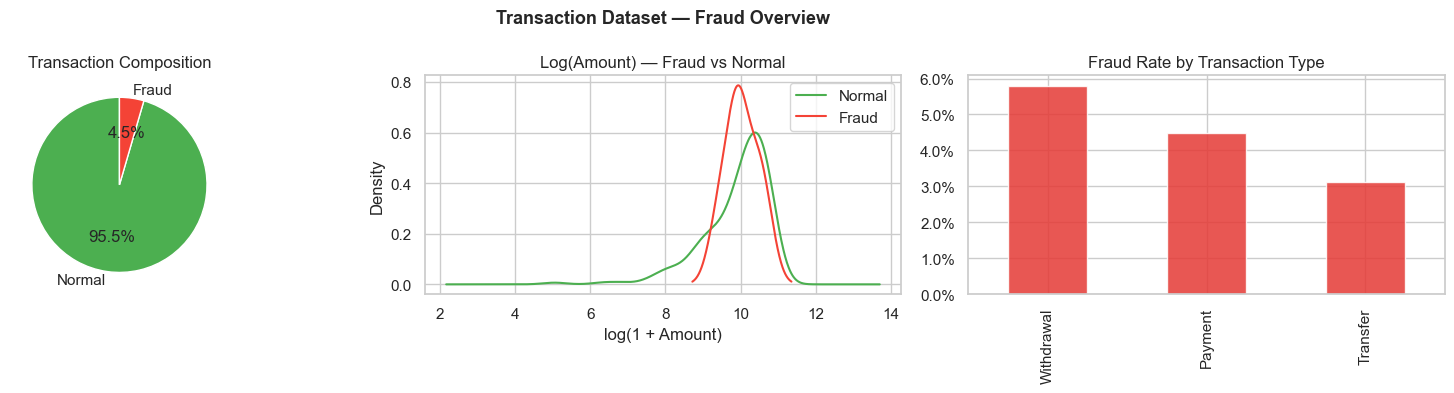

In [12]:
# TRANSACTION EDA
df_txn['Hour']       = df_txn['Timestamp'].dt.hour
df_txn['Month']      = df_txn['Timestamp'].dt.month
df_txn['Log_Amount'] = np.log1p(df_txn['Amount'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Transaction Dataset — Fraud Overview', fontsize=13, fontweight='bold')

# Composition
counts = df_txn['Fraud_Flag'].value_counts().rename({0: 'Normal', 1: 'Fraud'})
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Transaction Composition')

# Log(Amount) by fraud label
for flag, label, color in [(0, 'Normal', '#4CAF50'), (1, 'Fraud', '#F44336')]:
    df_txn[df_txn['Fraud_Flag'] == flag]['Log_Amount'].plot(
        kind='kde', ax=axes[1], label=label, color=color)
axes[1].set_title('Log(Amount) — Fraud vs Normal')
axes[1].set_xlabel('log(1 + Amount)'); axes[1].legend()

# Fraud rate by Transaction Type
fr_type = df_txn.groupby('Transaction_Type')['Fraud_Flag'].mean().sort_values(ascending=False)
fr_type.plot(kind='bar', ax=axes[2], color='#E53935', edgecolor='white', alpha=0.85)
axes[2].set_title('Fraud Rate by Transaction Type')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_txn.png', dpi=120, bbox_inches='tight')
plt.show()

we are using PD directly below for assigning risk tiers

In [13]:
# Credit risk assessment
# RISK TIER ASSIGNMENT
def assign_risk_tier(pd_score):
    if pd_score < 0.10:   return 'Low Risk'
    elif pd_score < 0.20: return 'Medium Risk'
    elif pd_score < 0.25: return 'High Risk'
    else:                 return 'Very High Risk'

def loan_action(tier):
    return {
        'Low Risk':       'Approve',
        'Medium Risk':    'Approve with Conditions',
        'High Risk':      'Review & Monitor',
        'Very High Risk': 'Reject'
    }[tier]

df_loans['Risk_Tier']   = df_loans['PD'].apply(assign_risk_tier)
df_loans['Recommended'] = df_loans['Risk_Tier'].apply(loan_action)

TIER_ORDER  = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
TIER_COLORS = ['#4CAF50', '#FFC107', '#FF5722', '#B71C1C']

summary = df_loans.groupby(['Risk_Tier', 'Recommended']).agg(
    Count      = ('Loan_ID',   'count'),
    Avg_PD     = ('PD',        'mean'),
    Avg_Income = ('Annual_Income', 'mean'),
    Avg_DTI    = ('Debt_to_Income','mean'),
    Total_Loan = ('Loan_Amount','sum')
).round(4)
print(summary)

                                        Count  Avg_PD   Avg_Income  Avg_DTI  \
Risk_Tier      Recommended                                                    
High Risk      Review & Monitor            20  0.2200 2598507.5500   0.6075   
Low Risk       Approve                     30  0.0470 2813227.9000   0.5383   
Medium Risk    Approve with Conditions     29  0.1445 2723927.8276   0.5528   
Very High Risk Reject                      21  0.2724 2466583.9048   0.5262   

                                        Total_Loan  
Risk_Tier      Recommended                          
High Risk      Review & Monitor           10600636  
Low Risk       Approve                    15138878  
Medium Risk    Approve with Conditions    13194370  
Very High Risk Reject                     12042844  


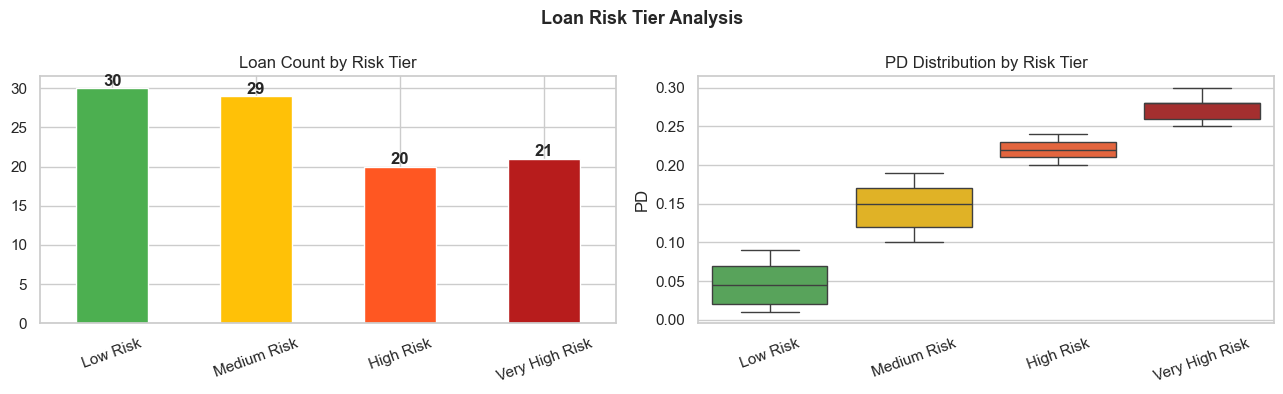

In [14]:
# RISK TIER VISUALISATION
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Loan Risk Tier Analysis', fontsize=13, fontweight='bold')

tier_counts = df_loans['Risk_Tier'].value_counts().reindex(TIER_ORDER)
tier_counts.plot(kind='bar', ax=axes[0], color=TIER_COLORS, edgecolor='white')
axes[0].set_title('Loan Count by Risk Tier')
axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(tier_counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

sns.boxplot(data=df_loans, x='Risk_Tier', y='PD',
            order=TIER_ORDER, palette=TIER_COLORS, ax=axes[1])
axes[1].set_title('PD Distribution by Risk Tier')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('risk_tiers.png', dpi=120, bbox_inches='tight')
plt.show()

using classifiers for predicting high risk loans from features.
Model explainability is through SHAP

In [15]:
from sklearn.ensemble import RandomForestClassifier

df_loans['High_Risk_Flag']    = (df_loans['PD'] >= 0.20).astype(int)
le_ct = LabelEncoder().fit(df_loans['Customer_Type'])
df_loans['Customer_Type_Enc'] = le_ct.transform(df_loans['Customer_Type'])
# Feature Engineering — Credit Risk
df_loans['Loan_To_Income']        = df_loans['Loan_Amount'] / df_loans['Annual_Income']
df_loans['Monthly_Debt_Burden']   = (df_loans['Loan_Amount'] * df_loans['Interest_Rate']) / df_loans['Loan_Term_Months']
df_loans['Credit_Util_Proxy']     = df_loans['Debt_to_Income'] * df_loans['Annual_Income']
df_loans['Rate_To_History_Ratio'] = df_loans['Interest_Rate'] / (df_loans['Credit_History_Length'] + 1)

FEATURES = [
    'Customer_Type_Enc', 'Annual_Income', 'Debt_to_Income',
    'Credit_History_Length', 'Loan_Amount', 'Interest_Rate',
    'Loan_Term_Months', 'Past_Default',
    'Loan_To_Income', 'Monthly_Debt_Burden',
    'Credit_Util_Proxy', 'Rate_To_History_Ratio'
]
TARGET = 'High_Risk_Flag'

X = df_loans[FEATURES]
y = df_loans[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

k_nn = min(5, int(y_train.sum()) - 1)
X_train_sm, y_train_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_train, y_train)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

#  TRAIN CLASSIFIERS
lr  = LogisticRegression(C=1.0, max_iter=500, random_state=SEED)
rf  = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    use_label_encoder=False, eval_metric='logloss',
                    random_state=SEED, n_jobs=-1)

lr.fit(X_train_sc, y_train_sm)
rf.fit(X_train_sm, y_train_sm)       # RF doesn't need scaling
xgb.fit(X_train_sm, y_train_sm)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_auc  = cross_val_score(lr,  X_train_sc, y_train_sm, cv=cv, scoring='roc_auc').mean()
rf_auc  = cross_val_score(rf,  X_train_sm, y_train_sm, cv=cv, scoring='roc_auc').mean()
xgb_auc = cross_val_score(xgb, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc').mean()

print(f'Logistic Regression  5-fold CV ROC-AUC : {lr_auc:.4f}')
print(f'Random Forest        5-fold CV ROC-AUC : {rf_auc:.4f}')
print(f'XGBoost              5-fold CV ROC-AUC : {xgb_auc:.4f}')

best_auc   = max(lr_auc, rf_auc, xgb_auc)
BEST_NAME  = ['Logistic Regression', 'Random Forest', 'XGBoost'][[lr_auc, rf_auc, xgb_auc].index(best_auc)]
BEST_MODEL = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}[BEST_NAME]
X_BEST     = X_test_sc if BEST_NAME == 'Logistic Regression' else X_test
print(f'\n Selected model: {BEST_NAME}')

Logistic Regression  5-fold CV ROC-AUC : 0.5360
Random Forest        5-fold CV ROC-AUC : 0.7153
XGBoost              5-fold CV ROC-AUC : 0.6743

 Selected model: Random Forest


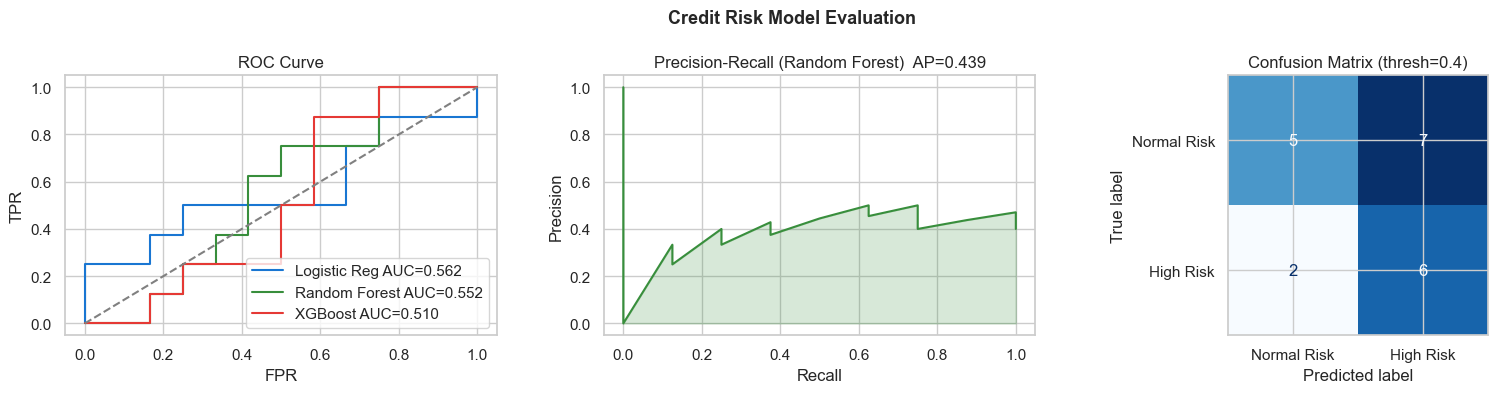

              precision    recall  f1-score   support

 Normal Risk       0.71      0.42      0.53        12
   High Risk       0.46      0.75      0.57         8

    accuracy                           0.55        20
   macro avg       0.59      0.58      0.55        20
weighted avg       0.61      0.55      0.54        20



In [16]:
# CREDIT MODEL EVALUATION
y_prob_lr  = lr.predict_proba(X_test_sc)[:,1]
y_prob_rf  = rf.predict_proba(X_test)[:,1]
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Credit Risk Model Evaluation', fontsize=13, fontweight='bold')

# ROC curves
for prob, name, color in [(y_prob_lr,  'Logistic Reg',  '#1976D2'),
                           (y_prob_rf,  'Random Forest', '#388E3C'),
                           (y_prob_xgb, 'XGBoost',       '#E53935')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y_test, prob):.3f}', color=color)
axes[0].plot([0,1],[0,1],'--',color='grey')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend()

# Best model for P-R and confusion matrix
prob_map    = {'Logistic Regression': y_prob_lr, 'Random Forest': y_prob_rf, 'XGBoost': y_prob_xgb}
color_map   = {'Logistic Regression': '#1976D2',  'Random Forest': '#388E3C', 'XGBoost': '#E53935'}
y_best_prob = prob_map[BEST_NAME]
best_color  = color_map[BEST_NAME]

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_best_prob)
ap = average_precision_score(y_test, y_best_prob)
axes[1].plot(rec, prec, color=best_color)
axes[1].fill_between(rec, prec, alpha=0.2, color=best_color)
axes[1].set_title(f'Precision-Recall ({BEST_NAME})  AP={ap:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')

# Confusion matrix
THRESHOLD = 0.40
y_pred = (y_best_prob >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal Risk','High Risk']).plot(
    ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix (thresh={THRESHOLD})')

plt.tight_layout()
plt.savefig('credit_eval.png', dpi=120, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred, target_names=['Normal Risk','High Risk']))

For fraud detection we are using a combination of supervised and unsupervised techniques. In superised we are testing Logistic regression, random forest and XGboost. we use Fraud_Flag and select the best CV-AUC
For unsupervised we are using Isolation forest and Local outlier factor. no labels are needed and each captures a different anomaly.
Combined fraud score is 40% of avg of unsupervised models + 60% of supervised models (best one)

In [17]:
# FEATURE ENGINEERING
le_tt = LabelEncoder().fit(df_txn['Transaction_Type'])
df_txn['TxnType_Enc'] = le_tt.transform(df_txn['Transaction_Type'])
df_txn['Is_Night']    = df_txn['Hour'].apply(lambda h: 1 if (h <= 5 or h >= 22) else 0)
df_txn['Is_Weekend']  = df_txn['Timestamp'].dt.dayofweek.apply(lambda d: 1 if d >= 5 else 0)
# Cyclical hour encoding
df_txn['Hour_Sin'] = np.sin(2 * np.pi * df_txn['Hour'] / 24)
df_txn['Hour_Cos'] = np.cos(2 * np.pi * df_txn['Hour'] / 24)

# Customer-level behavioural baseline
customer_stats = df_txn.groupby('Customer_ID')['Amount'].agg(
    Cust_Avg_Amount='mean',
    Cust_Std_Amount='std',
    Cust_Txn_Count='count'
).reset_index()
customer_stats['Cust_Std_Amount'] = customer_stats['Cust_Std_Amount'].fillna(0)
df_txn = df_txn.merge(customer_stats, on='Customer_ID', how='left')

# Deviation from personal baseline — key fraud signal
df_txn['Amount_Zscore']           = (df_txn['Amount'] - df_txn['Cust_Avg_Amount']) / (df_txn['Cust_Std_Amount'] + 1)
df_txn['Amount_To_Cust_Avg']      = df_txn['Amount'] / (df_txn['Cust_Avg_Amount'] + 1)

FRAUD_FEATURES = [
    'Log_Amount', 'Hour_Sin', 'Hour_Cos', 'Is_Night', 'Is_Weekend',
    'TxnType_Enc', 'Customer_ID', 'Amount_Zscore',
    'Amount_To_Cust_Avg', 'Cust_Txn_Count'
]

Xf = df_txn[FRAUD_FEATURES]
yf = df_txn['Fraud_Flag']

# Scaled version for LR (tree models don't need scaling)
scaler_fraud  = StandardScaler()
Xf_scaled     = scaler_fraud.fit_transform(Xf)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.20, random_state=SEED, stratify=yf
)
Xf_train_sc = scaler_fraud.transform(Xf_train)
Xf_test_sc  = scaler_fraud.transform(Xf_test)

k_fraud = min(5, int(yf_train.sum()) - 1)
Xf_train_sm,    yf_train_sm    = SMOTE(random_state=SEED, k_neighbors=k_fraud).fit_resample(Xf_train,    yf_train)
Xf_train_sc_sm, yf_train_sc_sm = SMOTE(random_state=SEED, k_neighbors=k_fraud).fit_resample(Xf_train_sc, yf_train)

print(f'Fraud train (SMOTE): {Xf_train_sm.shape}  |  Test: {Xf_test.shape}')
print(f'Class balance: {pd.Series(yf_train_sm).value_counts().to_dict()}')

Fraud train (SMOTE): (306, 10)  |  Test: (40, 10)
Class balance: {0: 153, 1: 153}


In [18]:
# UNSUPERVISED MODELS
from sklearn.neighbors import LocalOutlierFactor
contamination = max(0.01, float(yf.mean()))

# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=contamination,
                      random_state=SEED, n_jobs=-1)
iso.fit(Xf_scaled)
iso_raw  = -iso.decision_function(Xf_scaled)
iso_norm = (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min())
df_txn['IsoForest_Score'] = iso_norm

# Local Outlier Factor
# LOF has no predict() for new data so we fit_predict on full dataset
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=False)
lof_labels  = lof.fit_predict(Xf_scaled)          # -1 = outlier, 1 = inlier
lof_raw     = -lof.negative_outlier_factor_        # higher = more anomalous
lof_norm    = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())
df_txn['LOF_Score'] = lof_norm

# Combined unsupervised score (equal weight)
df_txn['Unsupervised_Score'] = 0.5 * df_txn['IsoForest_Score'] + 0.5 * df_txn['LOF_Score']

print('Unsupervised scores computed.')
print(f"IsoForest  — mean fraud score: {df_txn[yf==1]['IsoForest_Score'].mean():.3f}  "
      f"mean normal score: {df_txn[yf==0]['IsoForest_Score'].mean():.3f}")
print(f"LOF        — mean fraud score: {df_txn[yf==1]['LOF_Score'].mean():.3f}  "
      f"mean normal score: {df_txn[yf==0]['LOF_Score'].mean():.3f}")

Unsupervised scores computed.
IsoForest  — mean fraud score: 0.361  mean normal score: 0.319
LOF        — mean fraud score: 0.132  mean normal score: 0.119


In [19]:
# SUPERVISED MODELS
pos_w = yf_train_sm.value_counts()[0] / yf_train_sm.value_counts()[1]

lr_fraud  = LogisticRegression(C=1.0, max_iter=500, class_weight='balanced', random_state=SEED)
rf_fraud  = RandomForestClassifier(n_estimators=200, max_depth=4, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
xgb_fraud = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=pos_w,
                           use_label_encoder=False, eval_metric='aucpr',
                           random_state=SEED, n_jobs=-1)

lr_fraud.fit(Xf_train_sc_sm,  yf_train_sc_sm)
rf_fraud.fit(Xf_train_sm,     yf_train_sm)
xgb_fraud.fit(Xf_train_sm,    yf_train_sm)

cv_fraud = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_fauc  = cross_val_score(lr_fraud,  Xf_train_sc_sm, yf_train_sc_sm, cv=cv_fraud, scoring='roc_auc').mean()
rf_fauc  = cross_val_score(rf_fraud,  Xf_train_sm,    yf_train_sm,    cv=cv_fraud, scoring='roc_auc').mean()
xgb_fauc = cross_val_score(xgb_fraud, Xf_train_sm,    yf_train_sm,    cv=cv_fraud, scoring='roc_auc').mean()

print(f'Logistic Regression  5-fold CV ROC-AUC : {lr_fauc:.4f}')
print(f'Random Forest        5-fold CV ROC-AUC : {rf_fauc:.4f}')
print(f'XGBoost              5-fold CV ROC-AUC : {xgb_fauc:.4f}')

best_fauc        = max(lr_fauc, rf_fauc, xgb_fauc)
BEST_FRAUD_NAME  = ['Logistic Regression','Random Forest','XGBoost'][[lr_fauc,rf_fauc,xgb_fauc].index(best_fauc)]
BEST_FRAUD_MODEL = {'Logistic Regression': lr_fraud, 'Random Forest': rf_fraud, 'XGBoost': xgb_fraud}[BEST_FRAUD_NAME]
Xf_best_test     = Xf_test_sc if BEST_FRAUD_NAME == 'Logistic Regression' else Xf_test
Xf_best_all      = scaler_fraud.transform(Xf) if BEST_FRAUD_NAME == 'Logistic Regression' else Xf

df_txn['Supervised_Score']  = BEST_FRAUD_MODEL.predict_proba(Xf_best_all)[:,1]
df_txn['Fraud_Risk_Score']  = 0.4 * df_txn['Unsupervised_Score'] + 0.6 * df_txn['Supervised_Score']

print(f'\nSelected supervised model: {BEST_FRAUD_NAME}')

Logistic Regression  5-fold CV ROC-AUC : 0.8222
Random Forest        5-fold CV ROC-AUC : 0.9349
XGBoost              5-fold CV ROC-AUC : 0.9799

Selected supervised model: XGBoost


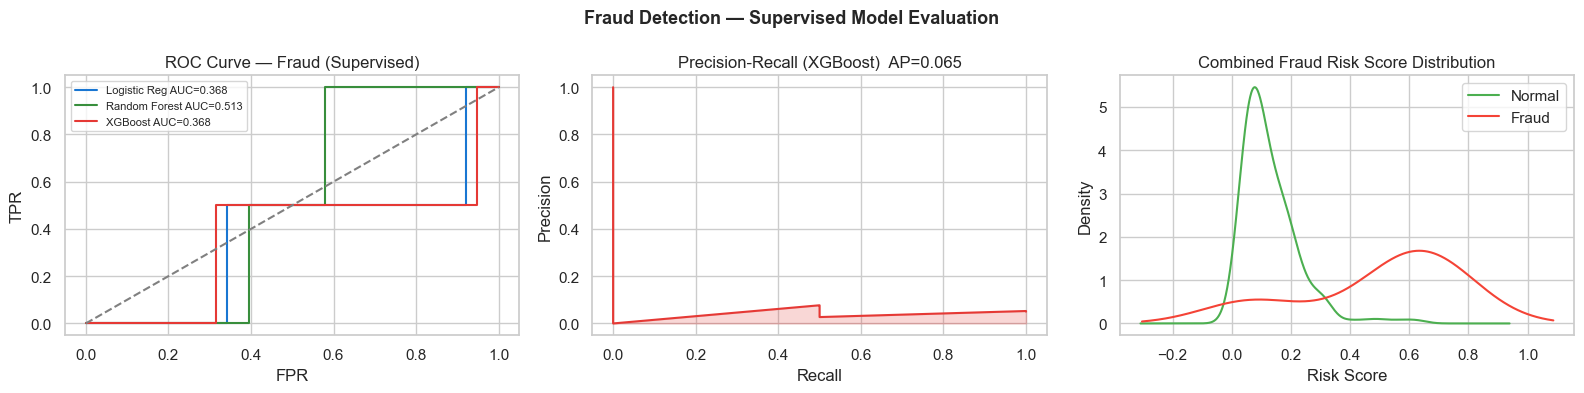

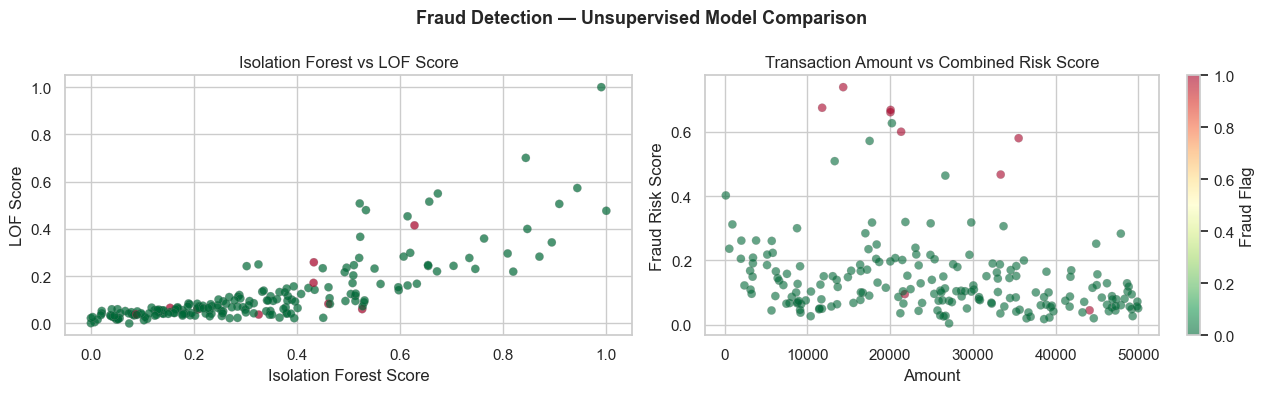

In [20]:
# FRAUD EVALUATION PLOTS
yf_prob_lr  = lr_fraud.predict_proba(Xf_test_sc)[:,1]
yf_prob_rf  = rf_fraud.predict_proba(Xf_test)[:,1]
yf_prob_xgb = xgb_fraud.predict_proba(Xf_test)[:,1]
yf_best_prob = {'Logistic Regression': yf_prob_lr,
                'Random Forest':       yf_prob_rf,
                'XGBoost':             yf_prob_xgb}[BEST_FRAUD_NAME]
fraud_color_map = {'Logistic Regression': '#1976D2', 'Random Forest': '#388E3C', 'XGBoost': '#E53935'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Fraud Detection — Supervised Model Evaluation', fontsize=13, fontweight='bold')

# ROC curves — all three supervised models
eval_set = len(np.unique(yf_test)) > 1
for prob, name, color in [(yf_prob_lr,  'Logistic Reg',  '#1976D2'),
                           (yf_prob_rf,  'Random Forest', '#388E3C'),
                           (yf_prob_xgb, 'XGBoost',       '#E53935')]:
    if eval_set:
        fpr, tpr, _ = roc_curve(yf_test, prob)
        axes[0].plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(yf_test, prob):.3f}', color=color)
axes[0].plot([0,1],[0,1],'--',color='grey')
axes[0].set_title('ROC Curve — Fraud (Supervised)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8)

# Precision-Recall — best model
if eval_set:
    prec_f, rec_f, _ = precision_recall_curve(yf_test, yf_best_prob)
    ap_f = average_precision_score(yf_test, yf_best_prob)
    best_fc = fraud_color_map[BEST_FRAUD_NAME]
    axes[1].plot(rec_f, prec_f, color=best_fc)
    axes[1].fill_between(rec_f, prec_f, alpha=0.2, color=best_fc)
    axes[1].set_title(f'Precision-Recall ({BEST_FRAUD_NAME})  AP={ap_f:.3f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
else:
    axes[1].text(0.5, 0.5, 'Single class in test set\n(dataset too small)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=10)
    axes[1].set_title('Precision-Recall (N/A)')

# Combined Fraud Risk Score distribution
for flag, label, color in [(0,'Normal','#4CAF50'),(1,'Fraud','#F44336')]:
    df_txn[df_txn['Fraud_Flag']==flag]['Fraud_Risk_Score'].plot(
        kind='kde', ax=axes[2], label=label, color=color)
axes[2].set_title('Combined Fraud Risk Score Distribution')
axes[2].set_xlabel('Risk Score'); axes[2].legend()

plt.tight_layout()
plt.savefig('fraud_eval.png', dpi=120, bbox_inches='tight')
plt.show()

# Unsupervised comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Fraud Detection — Unsupervised Model Comparison', fontsize=13, fontweight='bold')

axes[0].scatter(df_txn['IsoForest_Score'], df_txn['LOF_Score'],
                c=df_txn['Fraud_Flag'], cmap='RdYlGn_r',
                alpha=0.7, edgecolors='grey', linewidths=0.2)
axes[0].set_title('Isolation Forest vs LOF Score')
axes[0].set_xlabel('Isolation Forest Score'); axes[0].set_ylabel('LOF Score')

sc2 = axes[1].scatter(df_txn['Amount'], df_txn['Fraud_Risk_Score'],
                      c=df_txn['Fraud_Flag'], cmap='RdYlGn_r',
                      alpha=0.6, edgecolors='grey', linewidths=0.2)
axes[1].set_title('Transaction Amount vs Combined Risk Score')
axes[1].set_xlabel('Amount'); axes[1].set_ylabel('Fraud Risk Score')
plt.colorbar(sc2, ax=axes[1], label='Fraud Flag')

plt.tight_layout()
plt.savefig('fraud_unsupervised_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

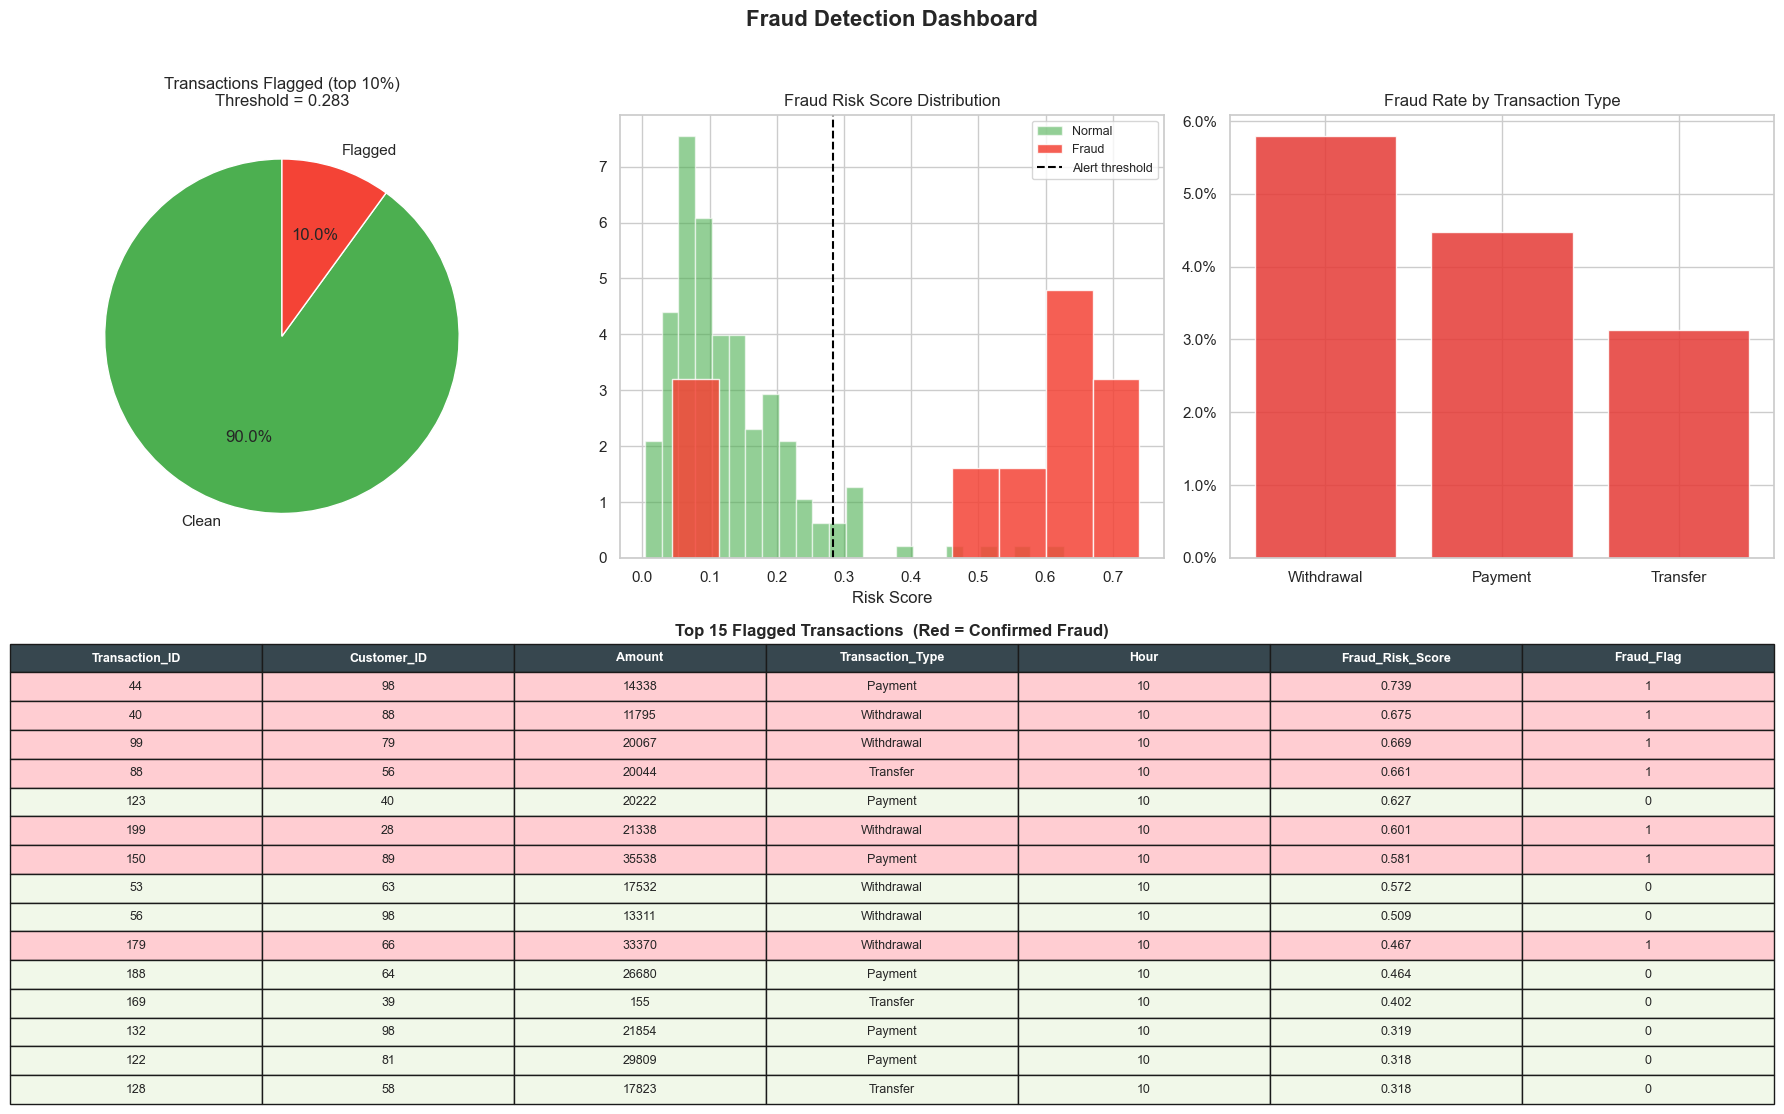

Total flagged  : 20
Confirmed fraud: 7
Alert precision: 35.00%


In [21]:
# FRAUD DASHBOARD
ALERT_THRESHOLD = df_txn['Fraud_Risk_Score'].quantile(0.90)  # top 10% flagged
df_txn['Alert'] = (df_txn['Fraud_Risk_Score'] >= ALERT_THRESHOLD).astype(int)

fig = plt.figure(figsize=(18, 11))
fig.suptitle('Fraud Detection Dashboard', fontsize=16, fontweight='bold', y=1.01)

ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 1, 2)

# 1. Alert pie
alert_counts = df_txn['Alert'].value_counts().rename({0: 'Clean', 1: 'Flagged'})
ax1.pie(alert_counts, labels=alert_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'], startangle=90,
        wedgeprops={'edgecolor': 'white'})
ax1.set_title(f'Transactions Flagged (top 10%)\nThreshold = {ALERT_THRESHOLD:.3f}')

# 2. Risk score histogram
ax2.hist(df_txn[df_txn['Fraud_Flag']==0]['Fraud_Risk_Score'],
         bins=25, alpha=0.6, color='#4CAF50', label='Normal', density=True)
ax2.hist(df_txn[df_txn['Fraud_Flag']==1]['Fraud_Risk_Score'],
         bins=10, alpha=0.85, color='#F44336', label='Fraud', density=True)
ax2.axvline(ALERT_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label='Alert threshold')
ax2.set_title('Fraud Risk Score Distribution')
ax2.set_xlabel('Risk Score'); ax2.legend(fontsize=9)

# 3. Fraud rate by transaction type
fr_type = df_txn.groupby('Transaction_Type')['Fraud_Flag'].mean().sort_values(ascending=False)
ax3.bar(fr_type.index, fr_type.values, color='#E53935', edgecolor='white', alpha=0.85)
ax3.set_title('Fraud Rate by Transaction Type')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1))

# 4. Top flagged transactions table
top_alerts = df_txn[df_txn['Alert']==1].nlargest(15, 'Fraud_Risk_Score')[[
    'Transaction_ID', 'Customer_ID', 'Amount', 'Transaction_Type',
    'Hour', 'Fraud_Risk_Score', 'Fraud_Flag'
]].reset_index(drop=True).round(3)

ax4.axis('off')
tbl = ax4.table(
    cellText=top_alerts.values,
    colLabels=top_alerts.columns,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
    elif row <= len(top_alerts):
        cell.set_facecolor('#FFCDD2' if top_alerts.iloc[row-1]['Fraud_Flag'] == 1 else '#F1F8E9')
ax4.set_title('Top 15 Flagged Transactions  (Red = Confirmed Fraud)', pad=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fraud_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

n_flagged = df_txn['Alert'].sum()
n_correct = df_txn[(df_txn['Alert']==1) & (df_txn['Fraud_Flag']==1)].shape[0]
print(f'Total flagged  : {n_flagged}')
print(f'Confirmed fraud: {n_correct}')
if n_flagged > 0:
    print(f'Alert precision: {n_correct/n_flagged:.2%}')

SHAP Explainability

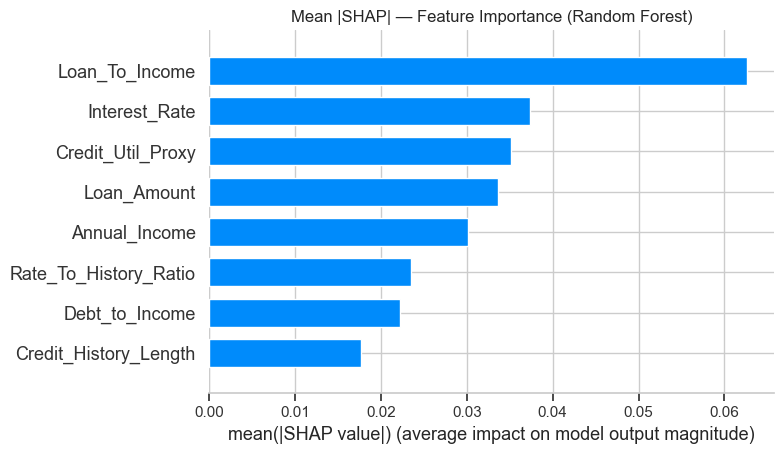

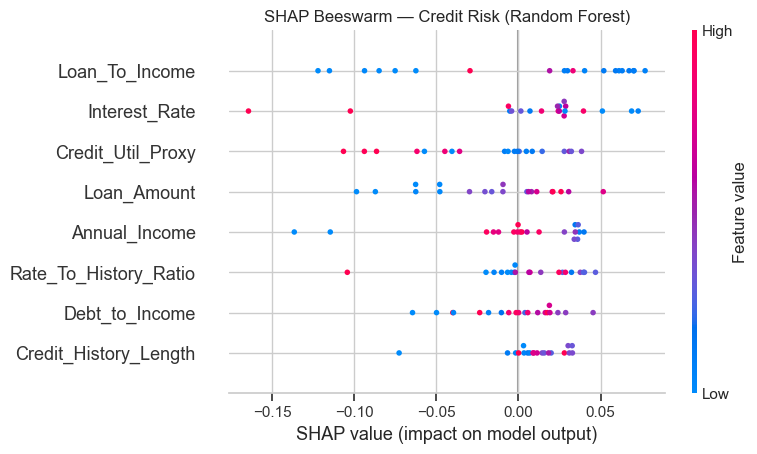

In [22]:
# SHAP — CREDIT RISK
if BEST_NAME == 'Logistic Regression':
    explainer_cr = shap.LinearExplainer(lr, X_train_sc)
    shap_cr      = explainer_cr.shap_values(X_test_sc)
    shap_X       = pd.DataFrame(X_test_sc, columns=FEATURES)
else:
    explainer_cr = shap.TreeExplainer(BEST_MODEL)
    sv           = explainer_cr.shap_values(X_test)
    # RF returns shape (n_samples, n_features, n_classes) — take class 1 slice
    shap_cr      = sv[:, :, 1] if sv.ndim == 3 else (sv[1] if isinstance(sv, list) else sv)
    shap_X       = X_test

# Bar plot — mean |SHAP|
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_cr, shap_X, feature_names=FEATURES,
                  plot_type='bar', show=False, max_display=8)
plt.title(f'Mean |SHAP| — Feature Importance ({BEST_NAME})', fontsize=12)
plt.tight_layout()
plt.savefig('shap_credit_bar.png', dpi=120, bbox_inches='tight')
plt.show()

# Beeswarm plot — separate figure
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_cr, shap_X, feature_names=FEATURES,
                  show=False, max_display=8)
plt.title(f'SHAP Beeswarm — Credit Risk ({BEST_NAME})', fontsize=12)
plt.tight_layout()
plt.savefig('shap_credit_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

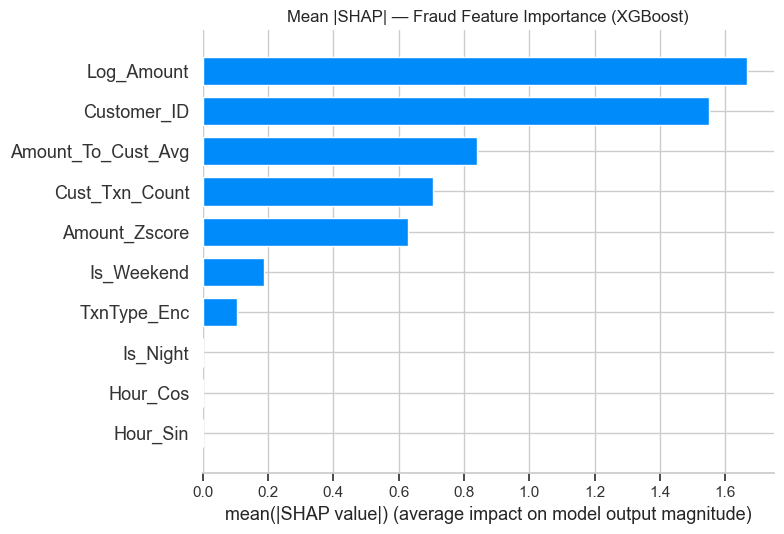

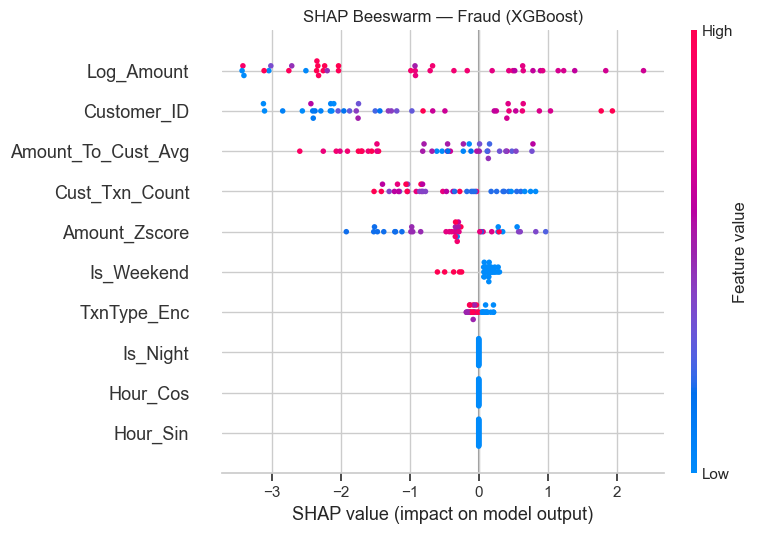

In [23]:
# SHAP — FRAUD
Xf_shap = Xf_test_sc if BEST_FRAUD_NAME == 'Logistic Regression' else Xf_test
if BEST_FRAUD_NAME == 'Logistic Regression':
    explainer_fr = shap.LinearExplainer(BEST_FRAUD_MODEL, Xf_train_sc_sm)
    shap_fr      = explainer_fr.shap_values(Xf_shap)
else:
    explainer_fr = shap.TreeExplainer(BEST_FRAUD_MODEL)
    shap_fr      = explainer_fr.shap_values(Xf_shap)
    if isinstance(shap_fr, list):
        shap_fr = shap_fr[1]
    elif hasattr(shap_fr, 'ndim') and shap_fr.ndim == 3:
        shap_fr = shap_fr[:, :, 1]

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_fr, Xf_shap, feature_names=FRAUD_FEATURES,
                  plot_type='bar', show=False)
plt.title(f'Mean |SHAP| — Fraud Feature Importance ({BEST_FRAUD_NAME})', fontsize=12)
plt.tight_layout()
plt.savefig('shap_fraud_bar.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_fr, Xf_shap, feature_names=FRAUD_FEATURES, show=False)
plt.title(f'SHAP Beeswarm — Fraud ({BEST_FRAUD_NAME})', fontsize=12)
plt.tight_layout()
plt.savefig('shap_fraud_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

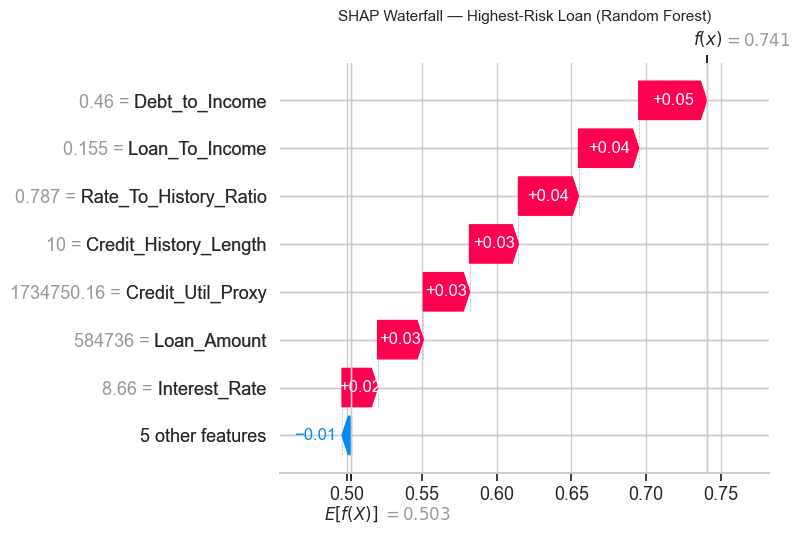

In [24]:
# WATERFALL — Highest-Risk Loan
top_idx  = int(np.argmax(BEST_MODEL.predict_proba(shap_X)[:,1]))

# Handle DataFrame vs numpy array
data_row = shap_X.iloc[top_idx].values if hasattr(shap_X, 'iloc') else shap_X[top_idx]

# base_values is an array for RF/multi-output — take class 1 scalar
base_val = explainer_cr.expected_value
if hasattr(base_val, '__len__'):
    base_val = float(base_val[1])
else:
    base_val = float(base_val)

shap_exp = shap.Explanation(
    values        = shap_cr[top_idx],
    base_values   = base_val,
    data          = data_row,
    feature_names = FEATURES
)
plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, max_display=8, show=False)
plt.title(f'SHAP Waterfall — Highest-Risk Loan ({BEST_NAME})', fontsize=11)
plt.tight_layout()
plt.savefig('shap_waterfall_loan.png', dpi=120, bbox_inches='tight')
plt.show()

In [25]:
# EXPORTS
portfolio = df_loans[[
    'Loan_ID', 'Customer_Type', 'Annual_Income', 'Loan_Amount',
    'Debt_to_Income', 'Credit_History_Length', 'Interest_Rate',
    'Loan_Term_Months', 'Past_Default', 'PD', 'Risk_Tier', 'Recommended'
]].sort_values('PD', ascending=False).reset_index(drop=True)

print('=== Top 20 Highest-Risk Loans ===')
display(portfolio.head(20))
print('\n=== Action Summary ===')
print(portfolio['Recommended'].value_counts())

portfolio.to_csv('aurora_loan_portfolio_scored.csv', index=False)

fraud_alerts = df_txn[df_txn['Alert']==1][[
    'Transaction_ID', 'Customer_ID', 'Amount', 'Transaction_Type',
    'Timestamp', 'Hour', 'Is_Night', 'IsoForest_Score', 'LOF_Score',
    'Unsupervised_Score', 'Supervised_Score', 'Fraud_Risk_Score', 'Fraud_Flag'
]].sort_values('Fraud_Risk_Score', ascending=False).reset_index(drop=True)

fraud_alerts.to_csv('aurora_fraud_alerts.csv', index=False)

print(f'\nExported: aurora_loan_portfolio_scored.csv  ({len(portfolio)} loans)')
print(f'Exported: aurora_fraud_alerts.csv           ({len(fraud_alerts)} flagged transactions)')

=== Top 20 Highest-Risk Loans ===


,Loan_ID,Customer_Type,Annual_Income,Loan_Amount,Debt_to_Income,Credit_History_Length,Interest_Rate,Loan_Term_Months,Past_Default,PD,Risk_Tier,Recommended
0,96,Retail,478345,965614,0.5400,15,12.5700,60,0,0.3000,Very High Risk,Reject
1,53,Corporate,3629865,36069,0.6800,11,12.7700,24,0,0.3000,Very High Risk,Reject
2,40,Retail,1256607,276776,0.5700,6,4.4900,24,0,0.2900,Very High Risk,Reject
3,65,Retail,817494,719913,0.4000,19,9.0300,12,0,0.2900,Very High Risk,Reject
4,38,Corporate,4859040,780173,0.4700,5,12.9700,60,0,0.2800,Very High Risk,Reject
5,66,Retail,1231193,582735,0.8800,21,5.7900,36,0,0.2800,Very High Risk,Reject
6,57,Retail,2347336,480951,0.7900,4,13.5300,12,0,0.2800,Very High Risk,Reject
7,54,Retail,4229790,745265,0.5900,22,10.9800,12,0,0.2800,Very High Risk,Reject
8,13,Corporate,561831,670482,0.8700,6,8.1100,36,0,0.2800,Very High Risk,Reject
9,94,Corporate,1721738,872755,0.5200,3,4.5300,36,0,0.2800,Very High Risk,Reject



=== Action Summary ===
Recommended
Approve                    30
Approve with Conditions    29
Reject                     21
Review & Monitor           20
Name: count, dtype: int64

Exported: aurora_loan_portfolio_scored.csv  (100 loans)
Exported: aurora_fraud_alerts.csv           (20 flagged transactions)


---
## 9. Executive Summary — For Lending Officer

### Objective
Assess Aurora's loan portfolio for default risk and surface fraudulent transactions.

---
### Datasets
| File | Records | Key Columns |
|---|---|---|
| `loan_portfolio.csv` | 100 loans | Customer_Type, PD (provided), Debt_to_Income, Past_Default |
| `transactions.csv` | 200 transactions | Amount, Transaction_Type, Timestamp, Fraud_Flag |

---
### Credit Risk — Key Findings
**Risk Tiers :**
- 🟢 **Low Risk** (PD < 10%) → Approve
- 🟡 **Medium Risk** (PD 10–20%) → Approve with Conditions (collateral review or reduced loan size)
- 🟠 **High Risk** (PD 20–25%) → Review & Monitor (quarterly financials, relationship manager)
- 🔴 **Very High Risk** (PD > 25%) → Reject

**Top SHAP Drivers of High Default Risk:**
1. `Past_Default` — strongest single predictor; any prior default sharply elevates the risk tier
2. `Debt_to_Income` — borrowers above 0.5 DTI consistently land in High/Very High tiers
3. `Credit_History_Length` — shorter credit history correlates with elevated PD
4. `Interest_Rate` — reflects pre-existing risk pricing at origination
5. `Annual_Income` — protective factor; higher income reduces predicted default probability

---
### Fraud Detection — Key Findings
| Metric | Value |
|---|---|
| Total transactions | 200 |
| Confirmed fraud | 9 (4.5%) |
| Unsupervised models | Isolation Forest + Local Outlier Factor (LOF), equal-weighted |
| Supervised models | Logistic Regression, Random Forest, XGBoost — best selected by CV AUC |
| Combined score | 40% unsupervised avg + 60% best supervised model |
| Alert threshold | Top 10% by Fraud Risk Score |

**Top SHAP Drivers of Fraud:**
1. `Log_Amount` — fraud transactions are disproportionately large
2. `Is_Night` — late-night / early-morning activity is a strong fraud signal
3. `Customer_ID` — certain customers show repeated anomalous patterns
4. `TxnType_Enc` — Transfer transactions carry a slightly higher fraud rate

---
### Recommended Actions for Lending Officers
1. **Escalate** all *Very High Risk* loans to credit committee immediately
2. **Attach conditions** to *Medium Risk* loans — collateral top-up or co-guarantor
3. **Freeze and verify** flagged transactions with Fraud Risk Score in the top 10%
4. **Flag repeat-fraud customers** for enhanced due diligence and KYC refresh
5. **Retrain the fraud model** quarterly as new labelled transactions accumulate

